In [44]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nilearn import datasets, plotting
from nilearn.maskers import NiftiLabelsMasker, NiftiMapsMasker
from nilearn.connectome import ConnectivityMeasure

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score, validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv('../abide/Phenotypic_V1_0b_preprocessed1.csv')

df[df['AGE_AT_SCAN'] <= 20].shape

(831, 106)

<Axes: xlabel='DX_GROUP', ylabel='count'>

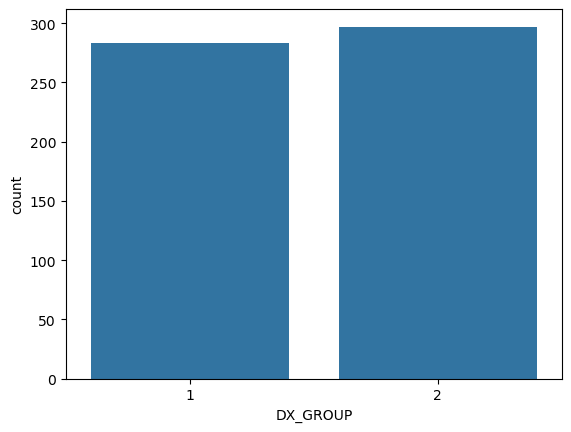

In [9]:
right = df[(df['HANDEDNESS_CATEGORY'] == 'R') & (df['SEX'] == 1)]
sns.countplot(x='DX_GROUP', data=right)


In [12]:
df[(df['HANDEDNESS_CATEGORY'] == 'R')]['DX_GROUP'].value_counts()

DX_GROUP
2    365
1    328
Name: count, dtype: int64

In [5]:
df_young = df[df['AGE_AT_SCAN'] <= 20]
df_young['DX_GROUP'].value_counts()

DX_GROUP
2    422
1    409
Name: count, dtype: int64

In [16]:
'SITE_ID' in df.columns

True

In [19]:
# Descriptive stats by site
df_right = df[(df['HANDEDNESS_CATEGORY'] == 'R')]

site_stats = df.groupby('SITE_ID').agg({
    'SUB_ID': 'count',
    'DX_GROUP': lambda x: x.value_counts().to_dict(),
    'SEX': lambda x: x.value_counts().to_dict(),
    'HANDEDNESS_CATEGORY': lambda x: x.value_counts().to_dict(),
    'AGE_AT_SCAN': ['mean', 'std', 'min', 'max']
}).round(2)

# Calculate balance metric for DX_GROUP
site_stats['dx_balance'] = df_right.groupby('SITE_ID')['DX_GROUP'].apply(
    lambda x: min(x.value_counts()) / max(x.value_counts()) if len(x.value_counts()) > 1 else 1.0
)

# Calculate age std as a metric
site_stats['age_std'] = df_right.groupby('SITE_ID')['AGE_AT_SCAN'].std()

# Sort by DX_GROUP balance (descending) and then by age_std (ascending)
site_stats = site_stats.sort_values(by=['dx_balance', 'age_std'], ascending=[False, True])

print("Site Statistics:\n")
print(f"{'SITE_ID':<12} {'N':<6} {'DX_GROUP':<30} {'SEX':<20} {'HANDEDNESS':<25} {'AGE: Mean±Std (Min-Max)'}")
print("="*130)

for site in df['SITE_ID'].unique():
    site_data = df[df['SITE_ID'] == site]
    n = len(site_data)
    dx = site_data['DX_GROUP'].value_counts().to_dict()
    sex = site_data['SEX'].value_counts().to_dict()
    hand = site_data['HANDEDNESS_CATEGORY'].value_counts().to_dict()
    age_mean = site_data['AGE_AT_SCAN'].mean()
    age_std = site_data['AGE_AT_SCAN'].std()
    age_min = site_data['AGE_AT_SCAN'].min()
    age_max = site_data['AGE_AT_SCAN'].max()
    
    print(f"{site:<12} {n:<6} {str(dx):<30} {str(sex):<20} {str(hand):<25} {age_mean:.1f}±{age_std:.1f} ({age_min:.1f}-{age_max:.1f})")

Site Statistics:

SITE_ID      N      DX_GROUP                       SEX                  HANDEDNESS                AGE: Mean±Std (Min-Max)
PITT         57     {1: 30, 2: 27}                 {1: 49, 2: 8}        {'R': 51, 'L': 4, 'Ambi': 1, '-9999': 1} 18.9±6.9 (9.3-35.2)
OLIN         36     {1: 20, 2: 16}                 {1: 31, 2: 5}        {'R': 30, 'L': 6}         16.8±3.5 (10.0-24.0)
OHSU         28     {2: 15, 1: 13}                 {1: 28}              {'R': 27, 'L': 1}         10.8±1.9 (8.0-15.2)
SDSU         36     {2: 22, 1: 14}                 {1: 29, 2: 7}        {'R': 32, 'L': 4}         14.4±1.8 (8.7-17.1)
TRINITY      49     {2: 25, 1: 24}                 {1: 49}              {'R': 49}                 17.2±3.6 (12.0-25.9)
UM_1         110    {1: 55, 2: 55}                 {1: 84, 2: 26}       {'R': 85, 'L': 14, '-9999': 9, 'Ambi': 1} 13.4±2.9 (8.2-19.2)
UM_2         35     {2: 22, 1: 13}                 {1: 33, 2: 2}        {'R': 31, 'L': 3, '-9999': 1} 16.0±3.3 (12.8-28

In [20]:
site_stats

SUB_ID         DX_GROUP              SEX  \
          count         <lambda>         <lambda>   
SITE_ID                                             
CMU          27   {1: 14, 2: 13}    {1: 21, 2: 6}   
PITT         57   {1: 30, 2: 27}    {1: 49, 2: 8}   
TRINITY      49   {2: 25, 1: 24}          {1: 49}   
CALTECH      38   {1: 19, 2: 19}    {1: 30, 2: 8}   
UM_1        110   {1: 55, 2: 55}   {1: 84, 2: 26}   
LEUVEN_1     29   {2: 15, 1: 14}          {1: 29}   
YALE         56   {2: 28, 1: 28}   {1: 40, 2: 16}   
OLIN         36   {1: 20, 2: 16}    {1: 31, 2: 5}   
STANFORD     40   {1: 20, 2: 20}    {1: 32, 2: 8}   
LEUVEN_2     35   {2: 20, 1: 15}    {1: 27, 2: 8}   
OHSU         28   {2: 15, 1: 13}          {1: 28}   
UCLA_2       27   {2: 14, 1: 13}    {1: 25, 2: 2}   
SDSU         36   {2: 22, 1: 14}    {1: 29, 2: 7}   
MAX_MUN      57   {2: 33, 1: 24}    {1: 50, 2: 7}   
UCLA_1       82   {1: 49, 2: 33}   {1: 71, 2: 11}   
KKI          55   {2: 33, 1: 22}   {1: 42, 2: 13}   
UM_2         35   {2: 22, 1: 13}    {1: 33, 2: 2}   
NYU         184  {2: 105, 1: 79}  {1: 147, 2: 37}   
SBL          30   {2: 15, 1: 15}          {1: 30}   
USM         101   {1: 58, 2: 43}         {1: 101}   

                                HANDEDNESS_CATEGORY AGE_AT_SCAN                \
                                           <lambda>        mean    std    min   
SITE_ID                                                                         
CMU                    {'R': 24, 'Ambi': 2, 'L': 1}       26.59   5.69  19.00   
PITT       {'R': 51, 'L': 4, 'Ambi': 1, '-9999': 1}       18.90   6.88   9.33   
TRINITY                                   {'R': 49}       17.18   3.64  12.00   
CALTECH                {'R': 29, 'Ambi': 8, 'L': 1}       28.16  10.64  17.00   
UM_1      {'R': 85, 'L': 14, '-9999': 9, 'Ambi': 1}       13.40   2.89   8.20   
LEUVEN_1                          {'R': 27, 'L': 2}       22.59   3.55  18.00   
YALE                             {'R': 46, 'L': 10}       12.71   2.88   7.00   
OLIN                              {'R': 30, 'L': 6}       16.81   3.49  10.00   
STANFORD               {'R': 33, 'L': 4, 'Ambi': 3}        9.96   1.58   7.53   
LEUVEN_2               {'R': 29, 'L': 5, 'L->R': 1}       14.16   1.42  12.10   
OHSU                              {'R': 27, 'L': 1}       10.81   1.87   8.00   
UCLA_2                            {'R': 23, 'L': 4}       12.46   1.50   9.79   
SDSU                              {'R': 32, 'L': 4}       14.41   1.84   8.67   
MAX_MUN                           {'R': 55, 'L': 2}       26.16  12.08   7.00   
UCLA_1                            {'R': 76, 'L': 6}       13.16   2.31   8.36   
KKI                   {'R': 46, 'Mixed': 6, 'L': 3}       10.10   1.33   8.07   
UM_2                  {'R': 31, 'L': 3, '-9999': 1}       15.96   3.32  12.80   
NYU                                              {}       15.25   6.58   6.47   
SBL                                        {'L': 1}       34.37   8.60  20.00   
USM                                              {}       22.10   7.68   8.77   

                dx_balance    age_std  
            max                        
SITE_ID                                
CMU       40.00   1.000000   5.415357  
PITT      35.20   0.961538   6.758802  
TRINITY   25.91   0.960000   3.638010  
CALTECH   56.20   0.933333  11.469772  
UM_1      19.20   0.931818   2.810820  
LEUVEN_1  32.00   0.928571   3.682174  
YALE      17.83   0.916667   2.872372  
OLIN      24.00   0.875000   3.233446  
STANFORD  12.94   0.833333   1.627651  
LEUVEN_2  16.90   0.812500   1.545795  
OHSU      15.23   0.800000   1.800162  
UCLA_2    16.47   0.769231   1.459787  
SDSU      17.15   0.684211   1.877709  
MAX_MUN   58.00   0.666667  12.271617  
UCLA_1    17.94   0.652174   2.270026  
KKI       12.77   0.642857   1.372024  
UM_2      28.80   0.550000   3.444772  
NYU       39.10        NaN        NaN  
SBL       64.00        NaN        NaN  
USM       50.22        NaN        NaN

In [21]:
abide = datasets.fetch_abide_pcp(band_pass_filtering=True, global_signal_regression=True, SITE_ID='PITT', HANDEDNESS_CATEGORY='R')

[fetch_abide_pcp] Dataset found in /home/iliu/nilearn_data/ABIDE_pcp

In [24]:
pheno = abide.phenotypic
func = abide.func_preproc

pheno.shape

(45, 106)

<Axes: xlabel='DX_GROUP', ylabel='count'>

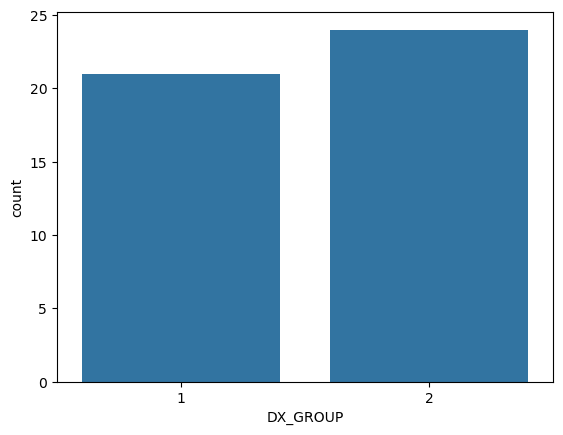

In [25]:
sns.countplot(x='DX_GROUP', data=pheno)

In [26]:
pheno['SEX'].value_counts()

SEX
1    38
2     7
Name: count, dtype: int64

# Feature Construction -- FC

In [ ]:
# DiFuMo atlas with 64 ROIs
difumo = datasets.fetch_atlas_difumo(dimension = 64)
difumo_img = difumo.maps

[fetch_atlas_difumo] Dataset found in /home/iliu/nilearn_data/difumo_atlases

In [31]:
# extract time series and compute corr-based FC
# stack vectors for all subjects

atlas_masker = NiftiMapsMasker(
    difumo_img, 
    standardize = True
)

conn_m = ConnectivityMeasure(
    kind = 'correlation',
    vectorize = True,
    discard_diagonal = True
)

all_features = []
for i, sub in enumerate(func):
    time_series = atlas_masker.fit_transform(sub)
    corr_vector = conn_m.fit_transform([time_series])[0]
    all_features.append(corr_vector)
    print("Processed subject {}/{}".format(i+1, len(func)))

Processed subject 1/45
Processed subject 2/45
Processed subject 3/45
Processed subject 4/45
Processed subject 5/45
Processed subject 6/45
Processed subject 7/45
Processed subject 8/45
Processed subject 9/45
Processed subject 10/45
Processed subject 11/45
Processed subject 12/45
Processed subject 13/45
Processed subject 14/45
Processed subject 15/45
Processed subject 16/45
Processed subject 17/45
Processed subject 18/45
Processed subject 19/45
Processed subject 20/45
Processed subject 21/45
Processed subject 22/45
Processed subject 23/45
Processed subject 24/45
Processed subject 25/45
Processed subject 26/45
Processed subject 27/45
Processed subject 28/45
Processed subject 29/45
Processed subject 30/45
Processed subject 31/45
Processed subject 32/45
Processed subject 33/45
Processed subject 34/45
Processed subject 35/45
Processed subject 36/45
Processed subject 37/45
Processed subject 38/45
Processed subject 39/45
Processed subject 40/45
Processed subject 41/45
Processed subject 42/45
P

In [34]:
np.savez_compressed('./Output/pitt_difumo064_FC', a = all_features)

In [35]:
X_difumo = np.array(all_features)

X_difumo.shape

(45, 2016)

Text(0.5, 1.0, 'ROI Connectivity across Subjects')

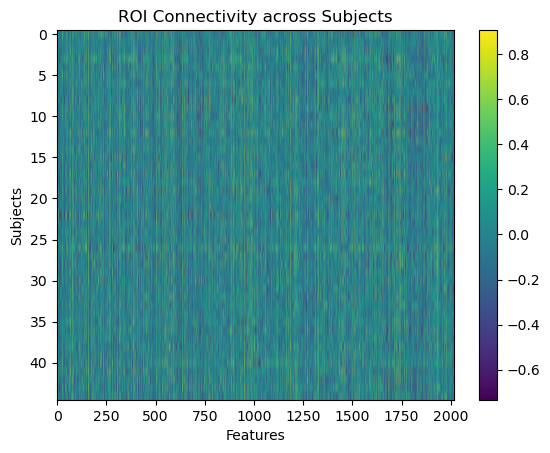

In [36]:
plt.imshow(
    X_difumo,
    aspect = 'auto'
)
plt.colorbar()
plt.xlabel('Features')
plt.ylabel('Subjects')
plt.title('ROI Connectivity across Subjects')

# Dataset Prep

In [ ]:
# 1 = ASD, 2 = TD
# turn TD label to 0

y_asd = np.array(pheno['DX_GROUP'].apply(lambda x: 0 if x == 2 else 1))

In [41]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_difumo,
    y_asd,
    test_size = 0.2,
    stratify = y_asd,
    shuffle = True,
    random_state = 42
)

In [42]:
# Feature standardization
scl = StandardScaler()
X_train_scl = scl.fit_transform(X_train)
X_test_scl = scl.transform(X_test)

# SVC

In [43]:
svc = SVC(
    kernel = 'linear',
    class_weight = 'balanced',
    random_state = 42
)

In [50]:
# CV to choose C
C_range = 10. ** np.arange(-3, 8)

train_scores, valid_scores = validation_curve(svc, X_train_scl, y_train, 
                                              param_name= "C",
                                              param_range = C_range,
                                              cv=3,
                                              scoring='r2')

In [51]:
tScores = pd.DataFrame(train_scores).stack().reset_index()
tScores.columns = ['C','Fold','Score']
tScores.loc[:,'Type'] = ['Train' for x in range(len(tScores))]

vScores = pd.DataFrame(valid_scores).stack().reset_index()
vScores.columns = ['C','Fold','Score']
vScores.loc[:,'Type'] = ['Validate' for x in range(len(vScores))]

ValCurves = pd.concat([tScores,vScores]).reset_index(drop=True)
ValCurves.head()

,C,Fold,Score,Type
0,0,0,1.0,Train
1,0,1,1.0,Train
2,0,2,1.0,Train
3,1,0,1.0,Train
4,1,1,1.0,Train


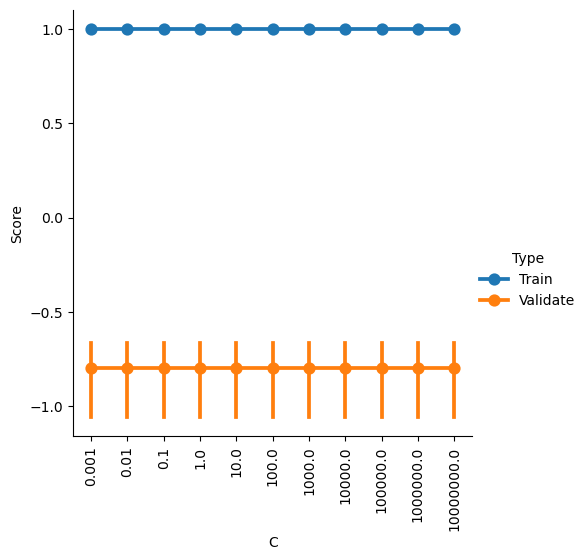

In [52]:
g = sns.catplot(x='C',y='Score',hue='Type',data=ValCurves,kind='point')
plt.xticks(range(11))
g.set_xticklabels(C_range, rotation=90)